In [1]:
# Full script: From attack type extraction to K-means clustering and visualization

import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("tanner_report.csv")

# Attack patterns
patterns = {
    "RFI": r".*\b(http|https|ftp|ftps):\/\/.*",
    "LFI": r".*(\.\./)*(home|proc|usr|etc)/.*",
    "XSS": r".*<[^>]+>.*",
    "SQLi": r".*\b(union\s+select|select\s+.*\s+from|insert\s+into|drop\s+table|--|\bor\b\s+\d+=\d+).*",
    "Command Injection": r".*\b(alias|cat|cd|cp|echo|exec|find|for|grep|ifconfig|ls|man|mkdir|netstat|ping|ps|pwd|uname|wget|touch|while)\b.*",
    "PHP Code Injection": r".*\b(eval\(|assert\(|base64_decode\().*",
    "PHP Object Injection": r".*[\{;]?\s*O:\d+:\".*?\":\d+:\{.*?\}.*",
    "CRLF": r".*(%0d%0a|\r\n).*",
    "XXE": r".*<\?(xml|!DOCTYPE).*?>.*",
    "Template Injection": r".*(\{\{.*?\}\}|\{%.*?%\}).*"
}

In [2]:
# Detect attack types from `path`
def detect_attack(path):
    for attack_type, pattern in patterns.items():
        if re.search(pattern, path, re.IGNORECASE):
            return attack_type
    return "Unknown"

df["attack_type"] = df["path"].apply(detect_attack)


In [3]:
# TF-IDF vectorization of the `path`
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df["path"])

# Aggregate TF-IDF vectors by session (sess_uuid)
session_features = pd.DataFrame(tfidf_matrix.toarray())
session_features["sess_uuid"] = df["sess_uuid"]
session_grouped = session_features.groupby("sess_uuid").mean()

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(session_grouped)

In [4]:
# K-Means clustering (optimal k is assumed, can be tuned)
kmeans = KMeans(n_clusters=5, random_state=42)
session_grouped["cluster"] = kmeans.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
session_grouped["PC1"] = components[:, 0]
session_grouped["PC2"] = components[:, 1]

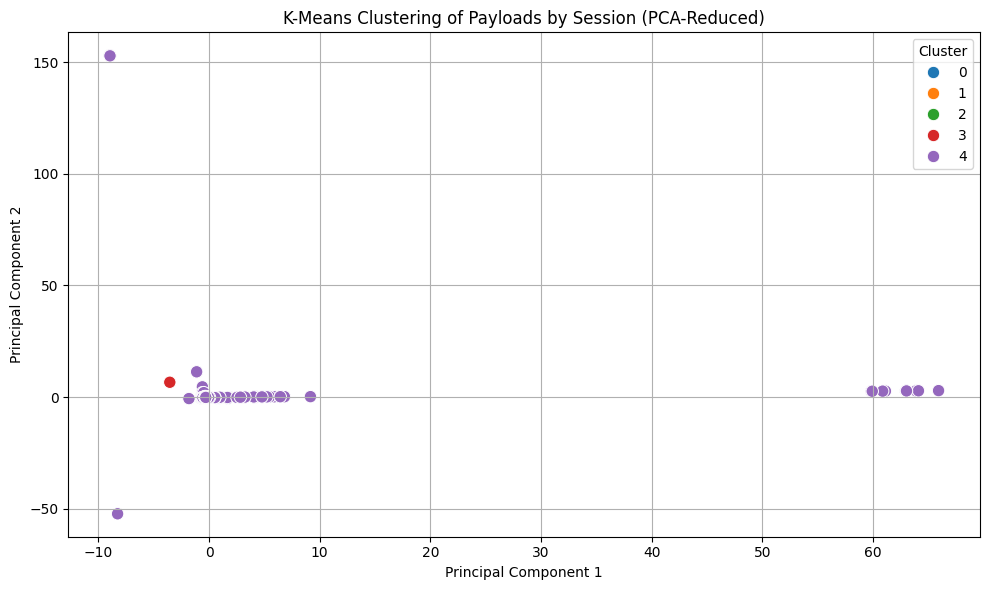

In [5]:
# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=session_grouped, x="PC1", y="PC2", hue="cluster", palette="tab10", s=80)
plt.title("K-Means Clustering of Payloads by Session (PCA-Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()